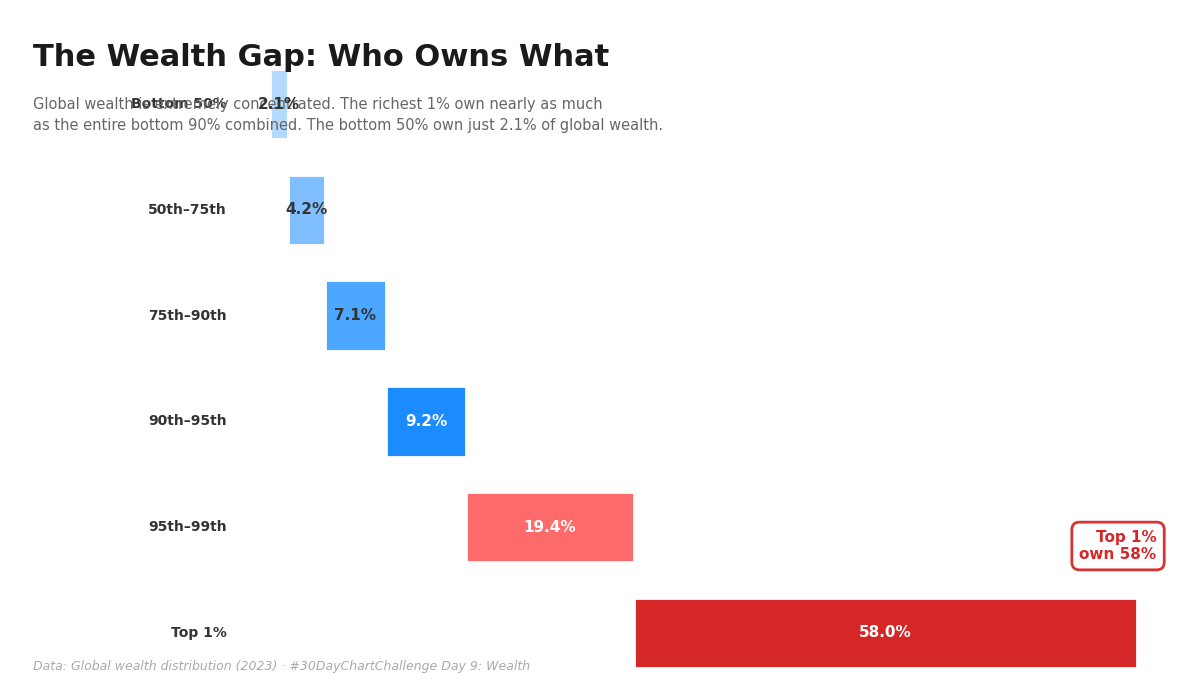

In [1]:
"""
#30DayChartChallenge — Day 9: Wealth
"Global Wealth Distribution" — inequality visualization
in the style of FlowingData: minimal chrome, direct labels, clean typography.

Data: Global wealth distribution by population percentile (2023)
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------------
# 1. SAMPLE DATA — Global wealth distribution (cumulative %)
# ---------------------------------------------------------------------------
data = {
    "Population_Percentile": [
        "Bottom 50%",
        "50th–75th",
        "75th–90th",
        "90th–95th",
        "95th–99th",
        "Top 1%"
    ],
    "Wealth_Share": [2.1, 4.2, 7.1, 9.2, 19.4, 58.0]
}

df = pd.DataFrame(data)

# Calculate cumulative for stacking effect
df["Cumulative"] = df["Wealth_Share"].cumsum()
df["Start"] = df["Cumulative"].shift(fill_value=0)

# ---------------------------------------------------------------------------
# 2. PLOT
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 7), facecolor="#FFFFFF")
ax.set_facecolor("#FFFFFF")

# Color palette: gradient from light to dark red (showing inequality)
colors = ["#b3d9ff", "#80bfff", "#4da6ff", "#1a8cff", "#ff6b6b", "#d62728"]

# Horizontal stacked bar chart
y_pos = 0
for i, (idx, row) in enumerate(df.iterrows()):
    ax.barh([y_pos], [row["Wealth_Share"]], left=row["Start"], 
            height=0.6, color=colors[i], edgecolor="white", linewidth=2, zorder=3)
    
    # Label in the middle of each segment
    mid_point = row["Start"] + row["Wealth_Share"] / 2
    ax.text(mid_point, y_pos, f"{row['Wealth_Share']:.1f}%",
            fontsize=11, fontweight="bold", color="white" if row["Wealth_Share"] > 8 else "#333333",
            ha="center", va="center", zorder=4)
    
    # Population label on the left
    ax.text(-5, y_pos, row["Population_Percentile"],
            fontsize=10, fontweight="600", color="#333333", ha="right", va="center")
    
    y_pos -= 0.9

# Minimal styling
ax.set_xlim(-30, 105)
ax.set_ylim(y_pos + 0.5, 0.8)
ax.axis("off")

# Title & subtitle
ax.text(0.02, 0.95, "The Wealth Gap: Who Owns What",
        fontsize=22, fontweight="bold", color="#1a1a1a", transform=ax.transAxes, va="top")

ax.text(0.02, 0.87,
        "Global wealth is extremely concentrated. The richest 1% own nearly as much\n"
        "as the entire bottom 90% combined. The bottom 50% own just 2.1% of global wealth.",
        fontsize=10.5, color="#666666", transform=ax.transAxes, va="top", linespacing=1.5)

# Annotation for top 1%
ax.text(0.98, 0.20, "Top 1%\nown 58%",
        fontsize=11, fontweight="bold", color="#d62728", transform=ax.transAxes, 
        ha="right", va="center", bbox=dict(boxstyle="round,pad=0.5",
        facecolor="#fff", edgecolor="#d62728", linewidth=2, alpha=0.95))

# Source
ax.text(0.02, 0.01,
        "Data: Global wealth distribution (2023) · #30DayChartChallenge Day 9: Wealth",
        fontsize=9, color="#aaaaaa", style="italic", transform=ax.transAxes, va="bottom")

plt.tight_layout()
plt.savefig("day9_wealth.png", dpi=200, facecolor="#FFFFFF", bbox_inches="tight")
plt.show()